This script will test my version vs Thomas's for the following:


- LCDM 
- Non interacting ncdm
- Interacting ncdm


In [ ]:
"""
compare_lcdm_fs_int_ncdm.py

Compare Thomas (CLASS wrapper: classy) vs Mine (classy_NEDE) in three clean regimes:

  0) ΛCDM baseline (no split keys; vanilla behavior)
  1) Free-streaming ncdm comparison:
       - Thomas: legacy ncdm keys (N_ncdm, m_ncdm, deg_ncdm)
       - Mine: split keys (N_ncdm_standard=1, N_ncdm_interacting=0) + legacy m/deg
  2) Interacting ncdm comparison:
       - Thomas: interacting interface keys (N_ncdm_interacting, m_ncdm_interacting, deg_ncdm_interacting, G_eff_ncdm_interacting)
       - Mine: split keys (N_ncdm_standard=0, N_ncdm_interacting=1) + legacy m/deg + G_eff_ncdm_interacting

We compute linear P(k,z=0) on a common physical k [1/Mpc] grid and convert to
(Mpc/h)^3 using Thomas h as reference for plotting.

This script is designed to avoid *any* accidental mixing of legacy + split interfaces.
"""


import numpy as np
import matplotlib.pyplot as plt

from classy import Class as ClassThomas
from classy_NEDE import Class as ClassMine


In [48]:
# =============================================================================
# Helpers
# =============================================================================
def pk_safe(cosmo, k_1Mpc_arr, z):
    fn = cosmo.pk_lin if hasattr(cosmo, "pk_lin") else cosmo.pk
    return np.array([fn(k, z) for k in k_1Mpc_arr])

def run(Cls, params, label):
    c = Cls()
    c.set(params)
    c.compute()
    try:
        d = c.get_current_derived_parameters(["h", "Omega_m", "Omega_r"])
        print(f"[{label}] derived:", d)
    except Exception:
        print(f"[{label}] h={c.h():.6f}")
    return c

def cleanup(*cosmos):
    for c in cosmos:
        try:
            c.struct_cleanup(); c.empty()
        except Exception:
            pass

def plot_two_panel(k_hMpc, Pk_T, Pk_M, title):
    dev = Pk_M / Pk_T - 1.0

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    ax1.loglog(k_hMpc, Pk_T, label="Thomas")
    ax1.loglog(k_hMpc, Pk_M, ls="--", label="Mine")
    ax1.set_ylabel(r"$P(k)\,[(\mathrm{Mpc}/h)^3]$")
    ax1.set_title(title)
    ax1.legend()
    ax1.grid(True, which="both", ls=":")

    ax2.semilogx(k_hMpc, dev)
    ax2.axhline(0.0, ls=":")
    ax2.set_xlabel(r"$k\,[h/\mathrm{Mpc}]$")
    ax2.set_ylabel("Mine/Thomas - 1")
    ax2.grid(True, which="both", ls=":")

    plt.tight_layout()
    plt.show()
    print(f"  max |Mine/Thomas - 1| = {np.max(np.abs(dev)):.3e}")

In [43]:
# =============================================================================
# BASE COSMOLOGICAL PARAMETERS (CLASS conventions)
# =============================================================================

# --- Standard ΛCDM ---
H0       = 67.32          # [km/s/Mpc] (use H0 OR h, not both)
omega_b  = 0.02238        # Ω_b h^2
omega_cdm= 0.1201         # Ω_cdm h^2
A_s      = 2.101e-9
n_s      = 0.9660
tau_reio = 0.0543
k_pivot  = 0.05           # [1/Mpc]
T_cmb    = 2.7255         # [K]
Omega_k  = 0.0

# --- Neutrino / ncdm baseline (default; will be overridden per run) ---
N_ncdm_base   = 1
m_ncdm_base   = 0.06       # [eV]
T_ncdm_base   = 0.71611    # T_ncdm / T_gamma
deg_ncdm_base = 1.0        # effective degeneracy carried by the massive species

# Radiation budget convention:
# keep total "3.046-like" budget fixed by subtracting massive degeneracy from N_ur
N_ur_base = max(0.0, 3.046 - float(deg_ncdm_base))

# --- Shared P(k) probe grid (physical k in 1/Mpc) ---
K_1MPC = np.logspace(-4, 1.0, 250)
Z_PK   = 0.0
L_MAX  = 2500


def base_params(lmax: int) -> dict:
    """Baseline parameter dict. Individual runs override neutrino keys explicitly."""
    return {
        # ΛCDM
        "H0"            : float(H0),
        "omega_b"       : float(omega_b),
        "omega_cdm"     : float(omega_cdm),
        "A_s"           : float(A_s),
        "n_s"           : float(n_s),
        "tau_reio"      : float(tau_reio),
        "k_pivot"       : float(k_pivot),
        "T_cmb"         : float(T_cmb),
        "Omega_k"       : float(Omega_k),

        # Neutrinos baseline (overridden per run below)
        "N_ur"          : float(N_ur_base),
        "N_ncdm"        : int(N_ncdm_base),
        "m_ncdm"        : float(m_ncdm_base),
        "T_ncdm"        : float(T_ncdm_base),
        "deg_ncdm"      : float(deg_ncdm_base),

        # Consistency knobs (avoid HyRec mismatch, etc.)
        "recombination"        : "recfast",
        "reio_parametrization" : "reio_camb",

        # Output
        "output"        : "tCl,pCl,lCl,mPk",
        "lensing"       : "yes",
        "l_max_scalars" : int(lmax),
        "P_k_max_1/Mpc" : float(np.max(K_1MPC) * 1.05),
    }


print("Base parameters loaded.")
print(f"  H0       = {H0} km/s/Mpc")
print(f"  omega_b  = {omega_b}")
print(f"  omega_cdm= {omega_cdm}")
print(f"  N_ur(base)= {N_ur_base:.6g}   (budget convention: 3.046 - deg_ncdm)")
print(f"  N_ncdm(base)= {N_ncdm_base}, m_ncdm(base)= {m_ncdm_base} eV, deg_ncdm(base)= {deg_ncdm_base}")
print(f"  k-grid   = [{K_1MPC.min():.1e}, {K_1MPC.max():.1e}] 1/Mpc  (N={len(K_1MPC)})")


Base parameters loaded.
  H0       = 67.32 km/s/Mpc
  omega_b  = 0.02238
  omega_cdm= 0.1201
  N_ur(base)= 2.046   (budget convention: 3.046 - deg_ncdm)
  N_ncdm(base)= 1, m_ncdm(base)= 0.06 eV, deg_ncdm(base)= 1.0
  k-grid   = [1.0e-04, 1.0e+01] 1/Mpc  (N=250)


Compute the LCDM power spectrum


RUN 0: Standard ΛCDM
has_efld = 0, Omega0_efld = 0.000000e+00, w0_efld = -1.000000e+00
[Thomas LCDM] h=0.673200
DEBUG split(prepass): legacy_flag=1 legacy_N=1  flag_std=0 flag_int=0  Nstd_in=0 Nint_in=0  => Nstd=1 Nint=0 Ntot=1 (local N_ncdm=1)
[Mine   LCDM] h=0.673200
DEBUG split(Geff_final): Nstd=1 Nint=0 Ntot=1  Geff_species=0.000e+00


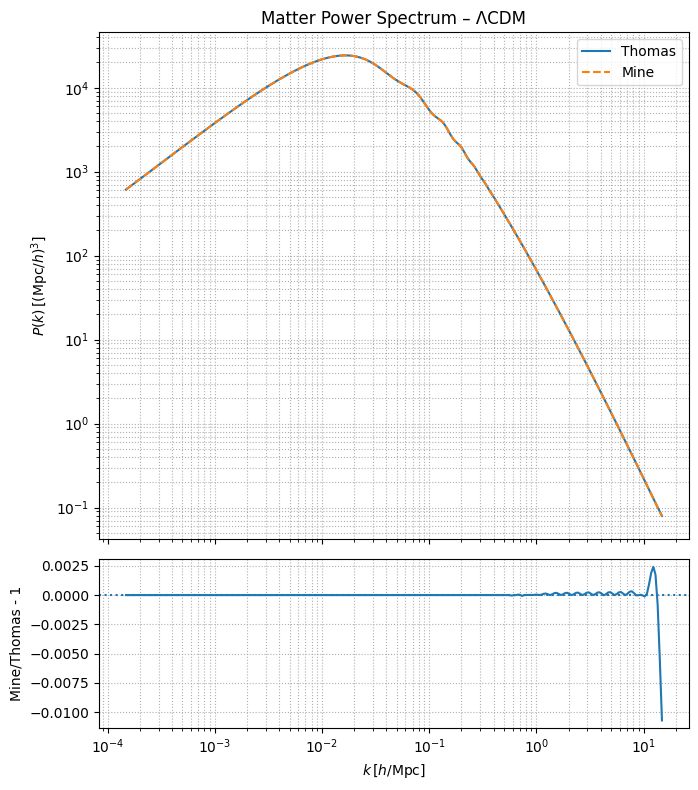

  max |Mine/Thomas - 1| = 1.071e-02


In [44]:
# =============================================================================
# 0) RUN: Standard ΛCDM (no split keys; no interacting interface)
# =============================================================================
print("\n==============================")
print("RUN 0: Standard ΛCDM")
print("==============================")

pT_lcdm = base_params(L_MAX)
pM_lcdm = base_params(L_MAX)

cT_lcdm = run(ClassThomas, pT_lcdm, "Thomas LCDM")
cM_lcdm = run(ClassMine,   pM_lcdm, "Mine   LCDM")

h_ref = float(cT_lcdm.h())
k_phys = K_1MPC
k_hMpc = K_1MPC / h_ref

PkT_lcdm = pk_safe(cT_lcdm, k_phys, Z_PK) * h_ref**3
PkM_lcdm = pk_safe(cM_lcdm, k_phys, Z_PK) * h_ref**3

plot_two_panel(k_hMpc, PkT_lcdm, PkM_lcdm, "Matter Power Spectrum – ΛCDM")

cleanup(cT_lcdm, cM_lcdm)



RUN 1: Free-streaming ncdm (FS)
[Thomas FS] h=0.673200
has_efld = 0, Omega0_efld = 0.000000e+00, w0_efld = -1.000000e+00
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=1 Nint_in=0  => Nstd=1 Nint=0 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=1 Nint=0 Ntot=1  Geff_species=0.000e+00
[Mine   FS] h=0.673200


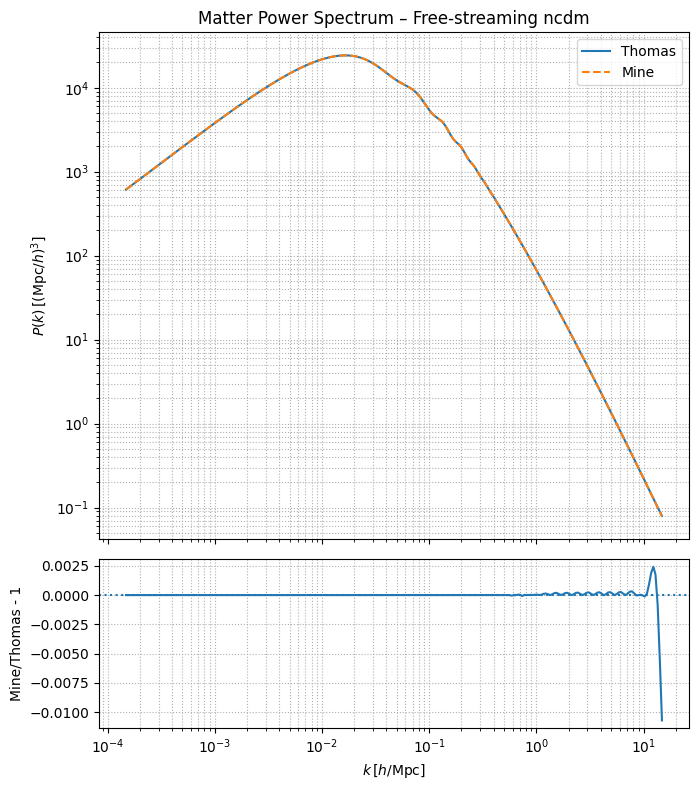

  max |Mine/Thomas - 1| = 1.071e-02


In [45]:
# =============================================================================
# 1) RUN: Free-streaming ncdm (FS) — clean interface separation
# =============================================================================
print("\n==============================")
print("RUN 1: Free-streaming ncdm (FS)")
print("==============================")

# knobs
M_NCDM_EV = 0.06
DEG_NCDM  = 1.0
N_ur_run  = max(0.0, 3.046 - float(DEG_NCDM))

# ----- Thomas: legacy ncdm keys -----
pT_fs = base_params(L_MAX)
pT_fs.update({
    "N_ur"     : float(N_ur_run),
    "N_ncdm"   : 1,
    "m_ncdm"   : float(M_NCDM_EV),
    "deg_ncdm" : float(DEG_NCDM),
    # T_ncdm stays baseline unless you want to override explicitly
})

# ----- Mine: split keys, STANDARD bucket -----
pM_fs = base_params(L_MAX)
pM_fs.update({
    "N_ur"               : float(N_ur_run),
    "N_ncdm_standard"    : 1,
    "N_ncdm_interacting" : 0,
    # Mine still reads mass/deg via legacy arrays (length=Ntot=1)
    "m_ncdm"             : float(M_NCDM_EV),
    "deg_ncdm"           : float(DEG_NCDM),
})
# avoid legacy/split conflict
pM_fs.pop("N_ncdm", None)

cT_fs = run(ClassThomas, pT_fs, "Thomas FS")
cM_fs = run(ClassMine,   pM_fs, "Mine   FS")

h_ref = float(cT_fs.h())
k_phys = K_1MPC
k_hMpc = K_1MPC / h_ref

PkT_fs = pk_safe(cT_fs, k_phys, Z_PK) * h_ref**3
PkM_fs = pk_safe(cM_fs, k_phys, Z_PK) * h_ref**3

plot_two_panel(k_hMpc, PkT_fs, PkM_fs, "Matter Power Spectrum – Free-streaming ncdm")

cleanup(cT_fs, cM_fs)


RUN 2: Interacting ncdm (INT)
has_efld = 0, Omega0_efld = 0.000000e+00, w0_efld = -1.000000e+00
[Thomas INT] h=0.673200
[Mine   INT] h=0.673200
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e-01


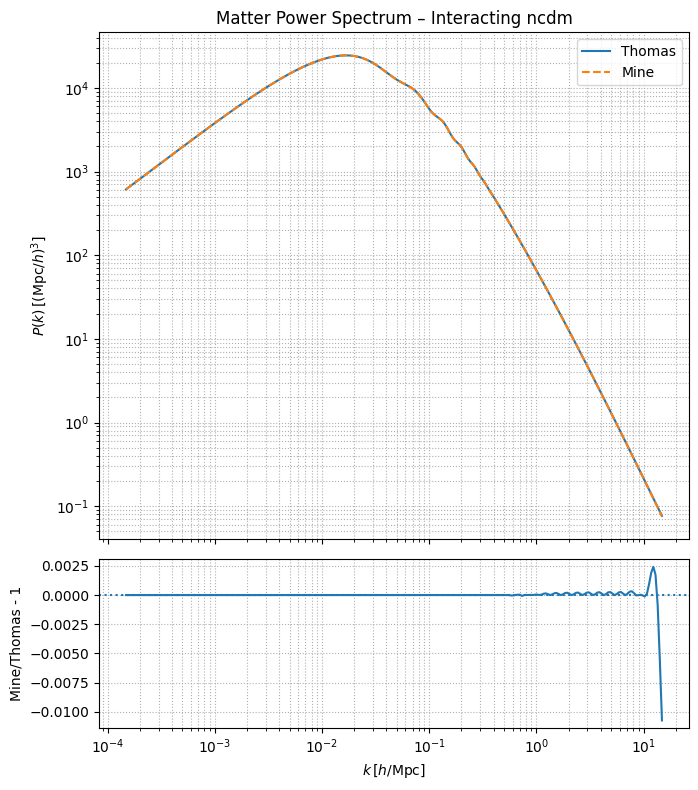

  max |Mine/Thomas - 1| = 1.074e-02

DONE.


In [46]:
# =============================================================================
# 2) RUN: Interacting ncdm (INT) — clean interface separation
# =============================================================================
print("\n==============================")
print("RUN 2: Interacting ncdm (INT)")
print("==============================")

G_EFF_NCDM_ON = 1e-1  # adjust as needed (indexing test, not physics)

# ----- Thomas: interacting interface keys only -----
pT_int = base_params(L_MAX)
pT_int.update({
    "N_ur"                 : float(N_ur_run),
    "N_ncdm_interacting"   : 1,
    "m_ncdm_interacting"   : float(M_NCDM_EV),
    "deg_ncdm_interacting" : float(DEG_NCDM),
    "G_eff_ncdm_interacting": float(G_EFF_NCDM_ON),
})
# remove legacy ncdm keys to avoid ambiguity
for key in ["N_ncdm", "m_ncdm", "deg_ncdm", "T_ncdm"]:
    pT_int.pop(key, None)

# ----- Mine: split keys, INTERACTING bucket -----
pM_int = base_params(L_MAX)
pM_int.update({
    "N_ur"               : float(N_ur_run),
    "N_ncdm_standard"    : 0,
    "N_ncdm_interacting" : 1,
    # Mine (currently) uses legacy arrays for m/deg unless you implement *_interacting parsing
    "m_ncdm"             : float(M_NCDM_EV),
    "deg_ncdm"           : float(DEG_NCDM),
    "G_eff_ncdm_interacting": float(G_EFF_NCDM_ON),
})
pM_int.pop("N_ncdm", None)

cT_int = run(ClassThomas, pT_int, "Thomas INT")
cM_int = run(ClassMine,   pM_int, "Mine   INT")

h_ref = float(cT_int.h())
k_phys = K_1MPC
k_hMpc = K_1MPC / h_ref

PkT_int = pk_safe(cT_int, k_phys, Z_PK) * h_ref**3
PkM_int = pk_safe(cM_int, k_phys, Z_PK) * h_ref**3

plot_two_panel(k_hMpc, PkT_int, PkM_int, "Matter Power Spectrum – Interacting ncdm")

cleanup(cT_int, cM_int)


print("\nDONE.")

DEBUG split(prepass): legacy_flag=1 legacy_N=1  flag_std=0 flag_int=0  Nstd_in=0 Nint_in=0  => Nstd=1 Nint=0 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=1 Nint=0 Ntot=1  Geff_species=[Mine ΛCDM] h=0.673200
[Mine FS ncdm] h=0.673200
0.000e+00
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=1 Nint_in=0  => Nstd=1 Nint=0 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=1 Nint=0 Ntot=1  Geff_species=0.000e+00
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e+06
[Mine INT ncdm] h=0.673200


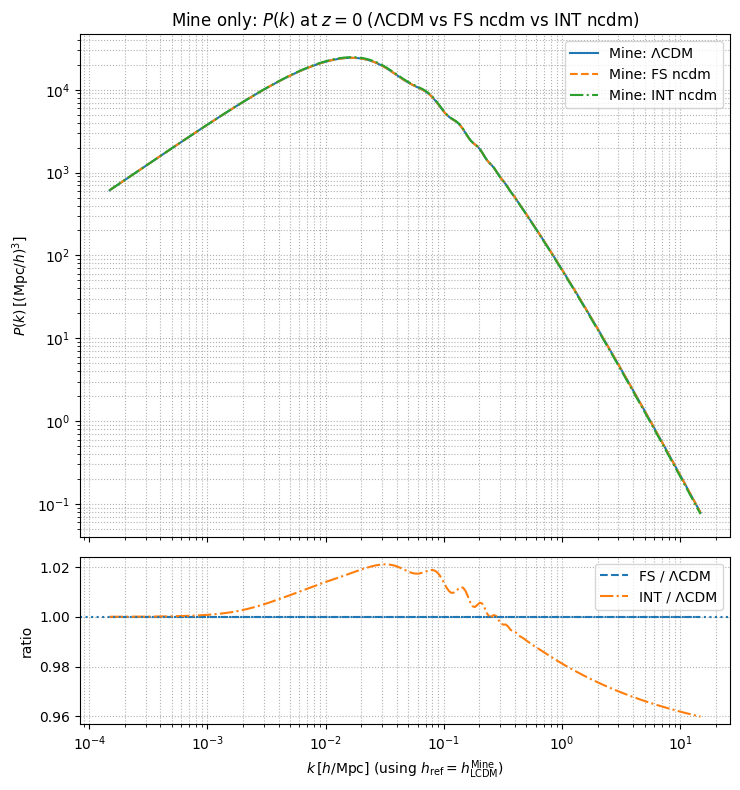

h_ref (Mine ΛCDM) = 0.673200
max |FS/LCDM - 1|  = 0.0
max |INT/LCDM - 1| = 0.04012463896791496


In [ ]:
# -----------------------------------------------------------------------------
# Mine-only: 2-panel plot
#   Top:   P(k) overlay  (ΛCDM vs FS ncdm vs INT ncdm)
#   Bottom: ratios to ΛCDM  (FS/LCDM and INT/LCDM). Remember that LCDM contain free streaming neutrinos, why FS should be on top of the first axis. 
# -----------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from classy_NEDE import Class as ClassMine

# -----------------------------
# Helpers
# -----------------------------
def pk_safe(cosmo, k_1Mpc_arr, z):
    fn = cosmo.pk_lin if hasattr(cosmo, "pk_lin") else cosmo.pk
    return np.array([fn(float(k), float(z)) for k in k_1Mpc_arr])

def run_mine(params, label):
    c = ClassMine()
    c.set(params)
    c.compute()
    try:
        d = c.get_current_derived_parameters(["h", "Omega_m", "Omega_r"])
        print(f"[{label}] derived:", d)
    except Exception:
        print(f"[{label}] h={c.h():.6f}")
    return c

def cleanup(*cosmos):
    for c in cosmos:
        try:
            c.struct_cleanup(); c.empty()
        except Exception:
            pass

# -----------------------------
# Knobs (match your conventions)
# -----------------------------
M_NCDM_EV     = 0.06
DEG_NCDM      = 1.0
N_ur_run      = max(0.0, 3.046 - float(DEG_NCDM))
G_EFF_NCDM_ON = 1e-1

# Uses your already-defined globals/functions:
#   - base_params(lmax)
#   - L_MAX, K_1MPC, Z_PK
# If not defined in this notebook cell, define them above.

# -----------------------------
# Build Mine parameter dicts
# -----------------------------
# 0) Mine ΛCDM (no split keys)
pM_lcdm = base_params(L_MAX)

# 1) Mine FS (split -> STANDARD bucket)
pM_fs = base_params(L_MAX)
pM_fs.update({
    "N_ur"               : float(N_ur_run),
    "N_ncdm_standard"    : 1,
    "N_ncdm_interacting" : 0,
    "m_ncdm"             : float(M_NCDM_EV),
    "deg_ncdm"           : float(DEG_NCDM),
})
pM_fs.pop("N_ncdm", None)  # avoid split/legacy conflict

# 2) Mine INT (split -> INTERACTING bucket)
pM_int = base_params(L_MAX)
pM_int.update({
    "N_ur"               : float(N_ur_run),
    "N_ncdm_standard"    : 0,
    "N_ncdm_interacting" : 1,
    "m_ncdm"             : float(M_NCDM_EV),
    "deg_ncdm"           : float(DEG_NCDM),
    "G_eff_ncdm_interacting": float(G_EFF_NCDM_ON),
})
pM_int.pop("N_ncdm", None)

# -----------------------------
# Run Mine only
# -----------------------------
cM_lcdm = run_mine(pM_lcdm, "Mine ΛCDM")
cM_fs   = run_mine(pM_fs,   "Mine FS ncdm")
cM_int  = run_mine(pM_int,  "Mine INT ncdm")

# -----------------------------
# Compute P(k) on common physical k [1/Mpc]
# Convert to (Mpc/h)^3 using ONE common reference h (Mine ΛCDM)
# -----------------------------
h_ref  = float(cM_lcdm.h())
k_phys = K_1MPC
k_hMpc = K_1MPC / h_ref

Pk_lcdm = pk_safe(cM_lcdm, k_phys, Z_PK) * h_ref**3
Pk_fs   = pk_safe(cM_fs,   k_phys, Z_PK) * h_ref**3
Pk_int  = pk_safe(cM_int,  k_phys, Z_PK) * h_ref**3

# Ratios to LCDM (Mine-only)
r_fs  = Pk_fs  / Pk_lcdm
r_int = Pk_int / Pk_lcdm

# -----------------------------
# Plot: 2 panels
# -----------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7.5, 8.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# Top: P(k)
ax1.loglog(k_hMpc, Pk_lcdm, label="Mine: ΛCDM")
ax1.loglog(k_hMpc, Pk_fs,   ls="--", label="Mine: FS ncdm")
ax1.loglog(k_hMpc, Pk_int,  ls="-.", label="Mine: INT ncdm")
ax1.set_ylabel(r"$P(k)\,[(\mathrm{Mpc}/h)^3]$")
ax1.set_title(r"Mine only: $P(k)$ at $z=0$ (ΛCDM vs FS ncdm vs INT ncdm)")
ax1.legend()
ax1.grid(True, which="both", ls=":")

# Bottom: ratios to LCDM
ax2.semilogx(k_hMpc, r_fs,  ls="--", label="FS / ΛCDM")
ax2.semilogx(k_hMpc, r_int, ls="-.", label="INT / ΛCDM")
ax2.axhline(1.0, ls=":")
ax2.set_xlabel(r"$k\,[h/\mathrm{Mpc}]$ (using $h_\mathrm{ref} = h_\mathrm{LCDM}^{\rm Mine}$)")
ax2.set_ylabel("ratio")
ax2.grid(True, which="both", ls=":")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"h_ref (Mine ΛCDM) = {h_ref:.6f}")
print("max |FS/LCDM - 1|  =", np.max(np.abs(r_fs  - 1.0)))
print("max |INT/LCDM - 1| =", np.max(np.abs(r_int - 1.0)))


cleanup(cM_lcdm, cM_fs, cM_int)